# street_crime Table Cleaning

pre-step: checks how many values are missing; checks distribution of crime types
1. Drops all rows with missing lsoa_code
2. Drops English crime data from the table
3. Groups crime types together based on plan
4. Checks for missing LSOAs, maps to police force areas, shows map of UK and the two police force areas with missing LSOAs
5. Creates new table lsoa_month

In [1]:
%pip install charset_normalizer

Note: you may need to restart the kernel to use updated packages.


In [2]:
import geopandas as gpd
import sqlite3
import pandas as pd
import holidays
import matplotlib.pyplot as plt
import libpysal
import seaborn as sns

conn = sqlite3.connect('../data/wales_data.db')
cursor = conn.cursor()

In [3]:
#pre-step; check how many values missing, check distribution of crime types
total_rows = pd.read_sql("SELECT COUNT(*) as total FROM street_crimes;", conn).iloc[0,0]
print(f'total rows {total_rows}')

null_query = """
SELECT 
    COUNT(*) - COUNT(crime_id) as missing_crime_id,
    COUNT(*) - COUNT(month) as missing_month,
    COUNT(*) - COUNT(longitude) as missing_long,
    COUNT(*) - COUNT(latitude) as missing_lat,
    COUNT(*) - COUNT(lsoa_code) as missing_lsoa,
    COUNT(*) - COUNT(crime_type) as missing_crime,
    COUNT(*) - COUNT(last_outcome) as missing_outcome
FROM street_crimes;
"""
null_df = pd.read_sql(null_query, conn)
null_percentages = (null_df / total_rows) * 100
display(null_percentages.round(2).astype(str) + '%')

crime_type_query = """
SELECT crime_type, COUNT(*) as incident_count 
FROM street_crimes 
GROUP BY crime_type 
ORDER BY incident_count DESC;
"""
crime_df = pd.read_sql(crime_type_query, conn)
crime_df['percentage'] = ((crime_df['incident_count'] / total_rows) * 100).round(2)
display(crime_df)

total rows 4674491


,missing_crime_id,missing_month,missing_long,missing_lat,missing_lsoa,missing_crime,missing_outcome
0,32.48%,0.0%,1.3%,1.3%,1.3%,0.0%,33.31%


,crime_type,incident_count,percentage
0,Anti-social behaviour,1336981,28.60
1,Violence and sexual offences,1166973,24.96
2,Criminal damage and arson,395453,8.46
3,Public order,307926,6.59
4,Other theft,307118,6.57
5,Shoplifting,267810,5.73
6,Burglary,217121,4.64
7,Vehicle crime,207461,4.44
8,Other crime,152988,3.27
9,Drugs,136765,2.93


In [4]:
#1 dropping all rows that have no lsoa_code in street_crimes

#count the rows before deletion
cursor.execute('SELECT COUNT(*) FROM street_crimes;')
count_before = cursor.fetchone()
print(f'count before deletion {count_before}')

#deletes all rows where lsoa_code is empty
delete = 'DELETE FROM street_crimes WHERE lsoa_code IS NULL;'
cursor.execute(delete)
conn.commit()

#count the rows after deletion
cursor.execute("SELECT COUNT(*) FROM street_crimes;")
count_after = cursor.fetchone()
print(f'count after deletion {count_before}')

count before deletion (4674491,)
count after deletion (4674491,)


In [5]:
#2 drop all Enlgish crime from street_crimes tables

#checking how many rows before deleting 
cursor.execute("SELECT COUNT(*) FROM street_crimes;")
count_before = cursor.fetchone()[0]
print(f'count before {count_before}')

#deleting w cursor, W% deletes any row where lsoa_code begins with W (welsh)
cursor.execute("DELETE FROM street_crimes WHERE lsoa_code LIKE 'E%';")

#commiting to db
conn.commit()

#checking how many rows after
cursor.execute("SELECT COUNT(*) FROM street_crimes;")
count_after = cursor.fetchone()[0]
print(f'count after {count_after}')

#difference
print(count_before - count_after)

count before 4613528
count after 4609286
4242


In [6]:
#3 grouping crime types together

#first deleting all other crime
cursor.execute("DELETE FROM street_crimes WHERE crime_type IN ('Other crime');")

#grouping violence
cursor.execute("""
    UPDATE street_crimes 
    SET crime_type = 'Violence' 
    WHERE crime_type IN ('Violence and sexual offences', 'Violent crime', 'Robbery');""")

#grouping property theft
cursor.execute("""
    UPDATE street_crimes 
    SET crime_type = 'Property theft' 
    WHERE crime_type IN ('Shoplifting', 'Theft from the person', 'Bicycle theft', 'Other theft');""")

#grouping disruptive crimes
cursor.execute("""
    UPDATE street_crimes 
    SET crime_type = 'Disruptive crimes' 
    WHERE crime_type IN ('Drugs', 'Possession of weapons', 'Public disorder and weapons', 'Public order');""")

conn.commit()

In [7]:
#3a check missing etc now that we've cleaned street_crimes
total_rows = pd.read_sql("SELECT COUNT(*) as total FROM street_crimes;", conn).iloc[0,0]
print(f'total rows {total_rows}')

null_query = """
SELECT 
    COUNT(*) - COUNT(crime_id) as missing_crime_id,
    COUNT(*) - COUNT(month) as missing_month,
    COUNT(*) - COUNT(longitude) as missing_long,
    COUNT(*) - COUNT(latitude) as missing_lat,
    COUNT(*) - COUNT(lsoa_code) as missing_lsoa,
    COUNT(*) - COUNT(crime_type) as missing_crime,
    COUNT(*) - COUNT(last_outcome) as missing_outcome
FROM street_crimes;
"""
null_df = pd.read_sql(null_query, conn)
null_percentages = (null_df / total_rows) * 100
display(null_percentages.round(2).astype(str) + '%')

crime_type_query = """
SELECT crime_type, COUNT(*) as incident_count 
FROM street_crimes 
GROUP BY crime_type 
ORDER BY incident_count DESC;
"""
crime_df = pd.read_sql(crime_type_query, conn)
crime_df['percentage'] = ((crime_df['incident_count'] / total_rows) * 100).round(2)
display(crime_df)

total rows 4457825


,missing_crime_id,missing_month,missing_long,missing_lat,missing_lsoa,missing_crime,missing_outcome
0,31.96%,0.0%,0.0%,0.0%,0.0%,0.0%,32.79%


,crime_type,incident_count,percentage
0,Anti-social behaviour,1323362,29.69
1,Violence,1236283,27.73
2,Property theft,619383,13.89
3,Disruptive crimes,469358,10.53
4,Criminal damage and arson,390719,8.76
5,Burglary,214524,4.81
6,Vehicle crime,204196,4.58


In [8]:
#4 checking for missing lsoas in street_crimes

#clean data gathered
clean_lsoas_df = pd.read_csv("../data/wimd-2025-index.csv", usecols=['LSOA code', 'LSOA name'])
total_lsoa_set = set(clean_lsoas_df['LSOA code'])

#get from db all lsoas
db_lsoas_df = pd.read_sql("SELECT lsoa_code FROM street_crimes;",  conn)
print(db_lsoas_df)

#i use set here so there are no duplicates
db_lsoa_set = set(db_lsoas_df['lsoa_code'])

#set difference to find which lsoa's missing from our db
missing_lsoas = total_lsoa_set - db_lsoa_set

print(f'total lsoa codes count (clean) {len(total_lsoa_set)}')
print(f'database lsoa codes count {len(db_lsoa_set)}')
print(f'number of missing lsoas {len(missing_lsoas)}')

#convert missing lsoas to series
missing_series = pd.Series(list(missing_lsoas))

print(missing_series.tolist())

unknown_lsoas = db_lsoa_set - total_lsoa_set
print(f'number of LSOAs that appeared in crime data but now known in WIMD {len(unknown_lsoas)}')
unknown_series = pd.Series(list(unknown_lsoas))

print(unknown_series.tolist())



         lsoa_code
0        W01000001
1        W01000001
2        W01000001
3        W01000001
4        W01000001
...            ...
4457820  W01002040
4457821  W01002040
4457822  W01002040
4457823  W01002040
4457824  W01002040

[4457825 rows x 1 columns]
total lsoa codes count (clean) 1917
database lsoa codes count 1988
number of missing lsoas 1
['W01002024']
number of LSOAs that appeared in crime data but now known in WIMD 72
['W01001213', 'W01000069', 'W01000352', 'W01001647', 'W01001118', 'W01000616', 'W01000532', 'W01000773', 'W01000923', 'W01001934', 'W01000020', 'W01001183', 'W01001649', 'W01000726', 'W01000917', 'W01000544', 'W01001709', 'W01000621', 'W01000048', 'W01000079', 'W01001215', 'W01001938', 'W01000620', 'W01000049', 'W01000906', 'W01001191', 'W01000920', 'W01000998', 'W01000032', 'W01000796', 'W01001553', 'W01001161', 'W01001477', 'W01001945', 'W01000593', 'W01000529', 'W01000383', 'W01000902', 'W01001957', 'W01001672', 'W01001688', 'W01000001', 'W01000002', 'W010015

After inspection: all 72 LSOA codes that are in crime data, but not in WIMD, are LSOAs codes from 2011 that are no longer active. It does not affect our model as criminal records from that time are not passed to training data set.

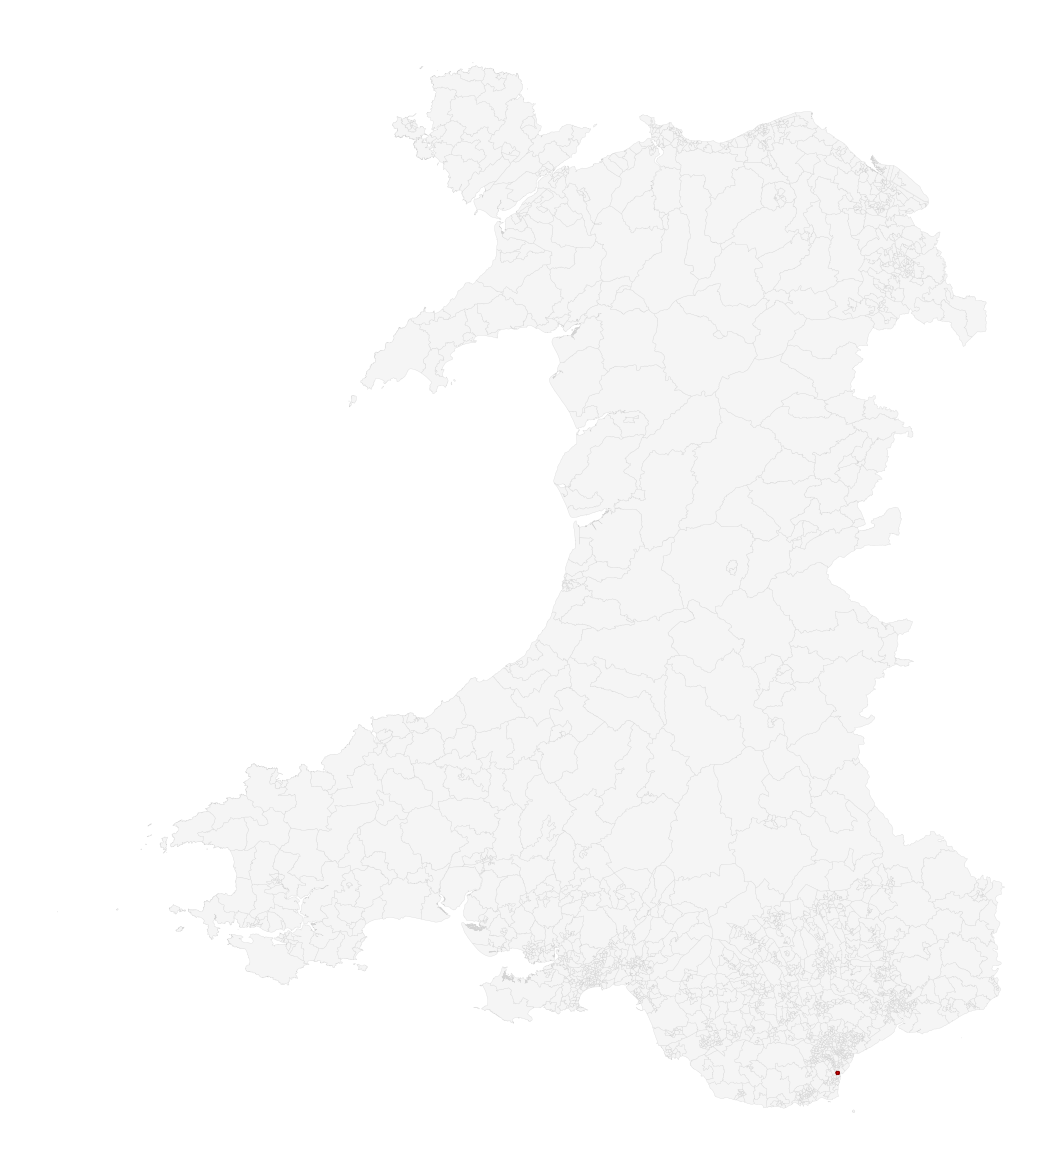

In [10]:
#4a plot missing lsoas
gdf = gpd.read_file('../data/lsoa_spatial.geojson') 

#separate between missing and normal lsoas
wales_base_map = gdf[~gdf['LSOA21CD'].str.startswith('E', na=False)]
missing_map_df = gdf[gdf['LSOA21CD'].isin(missing_series)]

fig, ax = plt.subplots(1, 1, figsize=(15, 15))

wales_base_map.plot(
    ax=ax, 
    color='whitesmoke', 
    edgecolor='lightgrey', 
    linewidth=0.2
)


if not missing_map_df.empty:
    missing_map_df.plot(
        ax=ax, 
        color='red', 
        edgecolor='darkred',
        linewidth=1
    )


ax.axis('off')

plt.savefig('../data/missing_lsoas_map_Wales.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
#4b map lsoa to police force area
#take all lsoa_code and pfa
df_info = pd.read_sql("SELECT lsoa_code, pfa_name FROM lsoa_info;", conn)

#filter df to only keep rows that have the missing codes
missing_auth_df = df_info[df_info['lsoa_code'].isin(missing_series)]

#count how many codes belong to each pfa
auth_summary = missing_auth_df['pfa_name'].value_counts()

display(auth_summary.to_frame)

#take all lsoa_code and local authority names
df_info = pd.read_sql("SELECT lsoa_code, pfa_name FROM lsoa_info;", conn)

#filtering for normal welsh lsoas; code can't be in missing code list
normal_auth_df = df_info[(~df_info['lsoa_code'].isin(missing_series))]

#count
normal_summary = normal_auth_df['pfa_name'].value_counts()

#don't hide rows
pd.set_option('display.max_rows', None)

display(normal_summary.to_frame())

<bound method Series.to_frame of pfa_name
South Wales    1
Name: count, dtype: int64>

,count
pfa_name,
South Wales,819
North Wales,417
Gwent,374
Dyfed-Powys,306


In [12]:
#4c check populations of missing lsoas

#join to get lsoa_info and lsoa_demographics together
query = """
SELECT 
    i.lsoa_code, 
    i.pfa_name, 
    d.pop as population
FROM lsoa_info i
LEFT JOIN lsoa_demographics d ON i.lsoa_code = d.lsoa_code;
"""
df_combined = pd.read_sql(query, conn)

#filter for only missing Welsh LSOAs
missing_df = df_combined[df_combined['lsoa_code'].isin(missing_series)]

display(missing_df.sort_values('population', ascending=True))

,lsoa_code,pfa_name,population
1900,W01002024,South Wales,1037


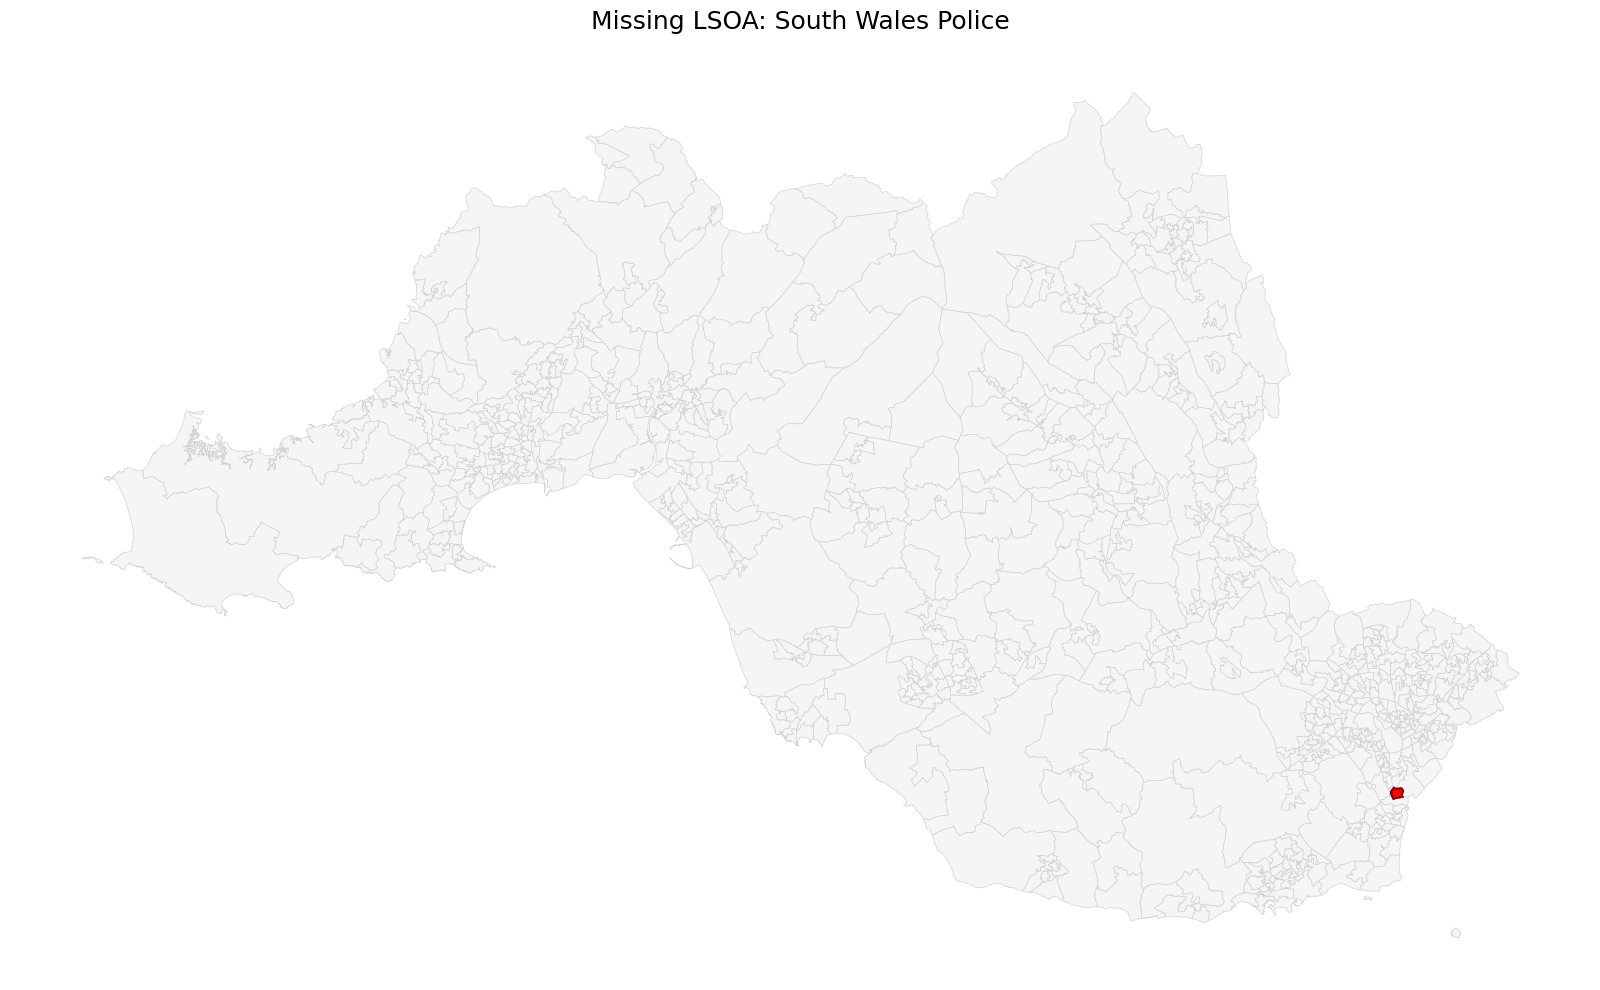

In [13]:
#4d make an in depth map of the area w/ missing lsoa
df_info = pd.read_sql("SELECT lsoa_code, pfa_name FROM lsoa_info;", conn)

gdf = gpd.read_file('../data/lsoa_spatial.geojson')

#merge shapes w/ police force names
map_with_police = gdf.merge(df_info, left_on='LSOA21CD', right_on='lsoa_code', how='inner')

#base map
south_wales_base = map_with_police[map_with_police['pfa_name'] == 'South Wales']

#grab the specific missing lsoas
south_wales_missing = south_wales_base[south_wales_base['LSOA21CD'].isin(missing_series)]

fig, ax1 = plt.subplots(1, 1, figsize=(20, 10))

#the map
south_wales_base.plot(ax=ax1, color='whitesmoke', edgecolor='lightgrey', linewidth=0.5)
if not south_wales_missing.empty:
    south_wales_missing.plot(ax=ax1, color='red', edgecolor='darkred', linewidth=1.5)
ax1.axis('off')
ax1.set_title("Missing LSOA: South Wales Police", fontsize=18, pad=15)


# 7. Save and show
plt.tight_layout()
plt.savefig('../data/missing_indepth_map_Wales.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
#5 create new table lsoa_month

#deletes table if exists to let me re-run multiple times
cursor.execute("DROP TABLE IF EXISTS lsoa_month;")

create_table_query = """
CREATE TABLE lsoa_month (
    lsoa_code TEXT,
    month TEXT,
    crime_type TEXT,
    crime_count INTEGER,
    PRIMARY KEY (lsoa_code, month, crime_type)
);
"""
cursor.execute(create_table_query)


#zero-padding aggregation query
aggregate_insert_query = """
INSERT INTO lsoa_month (lsoa_code, month, crime_type, crime_count)

WITH 
    unique_lsoas AS (SELECT DISTINCT lsoa_code FROM street_crimes),
    unique_months AS (SELECT DISTINCT month FROM street_crimes),
    unique_crimes AS (SELECT DISTINCT crime_type FROM street_crimes),
    
    master_grid AS (
        SELECT l.lsoa_code, m.month, c.crime_type
        FROM unique_lsoas l
        CROSS JOIN unique_months m
        CROSS JOIN unique_crimes c
    ),
    
    actual_crimes AS (
        SELECT lsoa_code, month, crime_type, COUNT(*) as count
        FROM street_crimes
        GROUP BY lsoa_code, month, crime_type
    )

SELECT 
    g.lsoa_code, 
    g.month, 
    g.crime_type, 
    COALESCE(a.count, 0) as crime_count
FROM master_grid g
LEFT JOIN actual_crimes a 
    ON g.lsoa_code = a.lsoa_code 
    AND g.month = a.month 
    AND g.crime_type = a.crime_type;
"""
cursor.execute(aggregate_insert_query)
conn.commit()

#check
check_query = "SELECT * FROM lsoa_month LIMIT 10;"
check_df = pd.read_sql(check_query, conn)
display(check_df)

total_rows = pd.read_sql("SELECT COUNT(*) as total FROM lsoa_month;", conn).iloc[0,0]
print(total_rows)

,lsoa_code,month,crime_type,crime_count
0,W01000003,2010-12,Anti-social behaviour,18
1,W01000003,2010-12,Burglary,2
2,W01000003,2010-12,Violence,4
3,W01000003,2010-12,Vehicle crime,0
4,W01000003,2010-12,Disruptive crimes,0
5,W01000003,2010-12,Criminal damage and arson,0
6,W01000003,2010-12,Property theft,0
7,W01000003,2011-01,Anti-social behaviour,14
8,W01000003,2011-01,Burglary,0
9,W01000003,2011-01,Violence,2


2454396


In [15]:
zero_query = "SELECT COUNT(*) FROM lsoa_month WHERE crime_count = 0;"

zero_count = pd.read_sql(zero_query, conn).iloc[0, 0]
print(zero_count)

1106580
